# **Tanzania**

**Imports and Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("tanzania.csv")

df['Country'] = "Tanzania"

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} cols.")

Dataset loaded with 4108 rows and 13 cols.


**Missing Value Handling & Sentinels**

In [2]:
df.replace(~999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

null_reports = df.isna().sum()
null_percentage = (null_reports / len(df)) * 100

print(f"Duplicates removed: {duplicates}")
print("\nMissing Value Percentage per Column: ", end="")
print(null_percentage[null_percentage > 0])

Duplicates removed: 0

Missing Value Percentage per Column: Series([], dtype: float64)


**Data Parsing**

In [3]:
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df['Month'] = df['Date'].dt.month

df.set_index('Date', inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1


**Outlier Detection**

In [4]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

outliers = (z_scores > 3).sum()
print(f"Outlier counts: {outliers}")

df.ffill(inplace=True)

Outlier counts: 102


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,1
2015-01-02,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,1
2015-01-03,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,1
2015-01-04,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,1
2015-01-05,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,3
2026-03-28,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,3
2026-03-29,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,3


**Time Series Visualization**

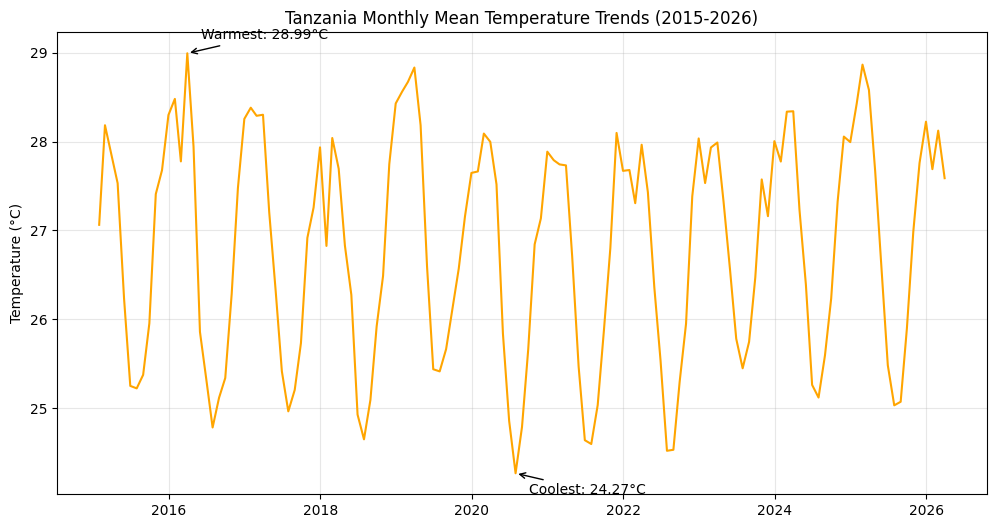

In [5]:
monthly_temps = df['T2M'].resample('ME').mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_temps, color='orange', label='Mean Temp (T2M)')

warmest = monthly_temps.idxmax()
coolest = monthly_temps.idxmin()

plt.annotate(f'Warmest: {monthly_temps.max():.2f}°C', xy=(warmest, monthly_temps.max()), 
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: {monthly_temps.min():.2f}°C', xy=(coolest, monthly_temps.min()), 
             xytext=(10, -15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Tanzania Monthly Mean Temperature Trends (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

**Precipitation Analysis**

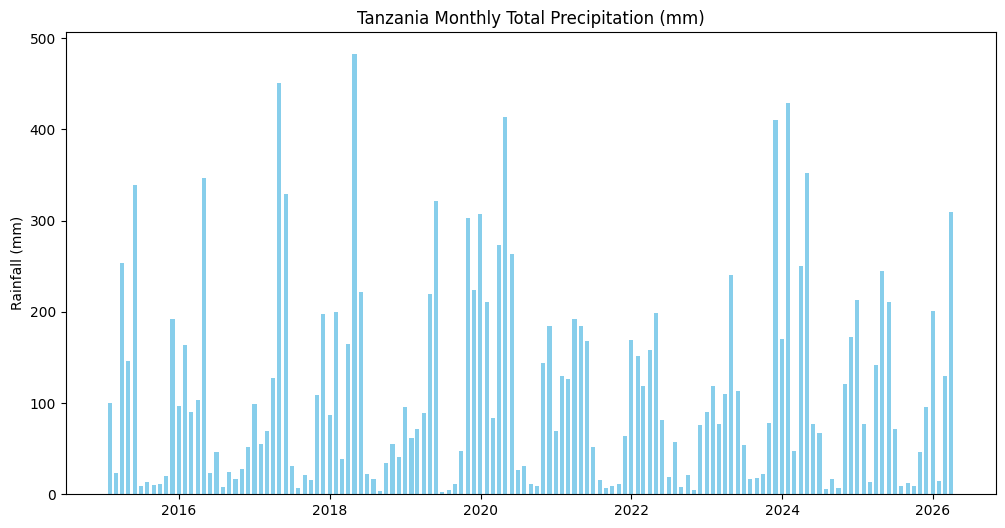

In [6]:
monthly_precip = df['PRECTOTCORR'].resample('ME').sum()

plt.figure(figsize=(12,6))
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='skyblue')
plt.title('Tanzania Monthly Total Precipitation (mm)')
plt.ylabel('Rainfall (mm)')

plt.show()

**Correlation Heatmap**

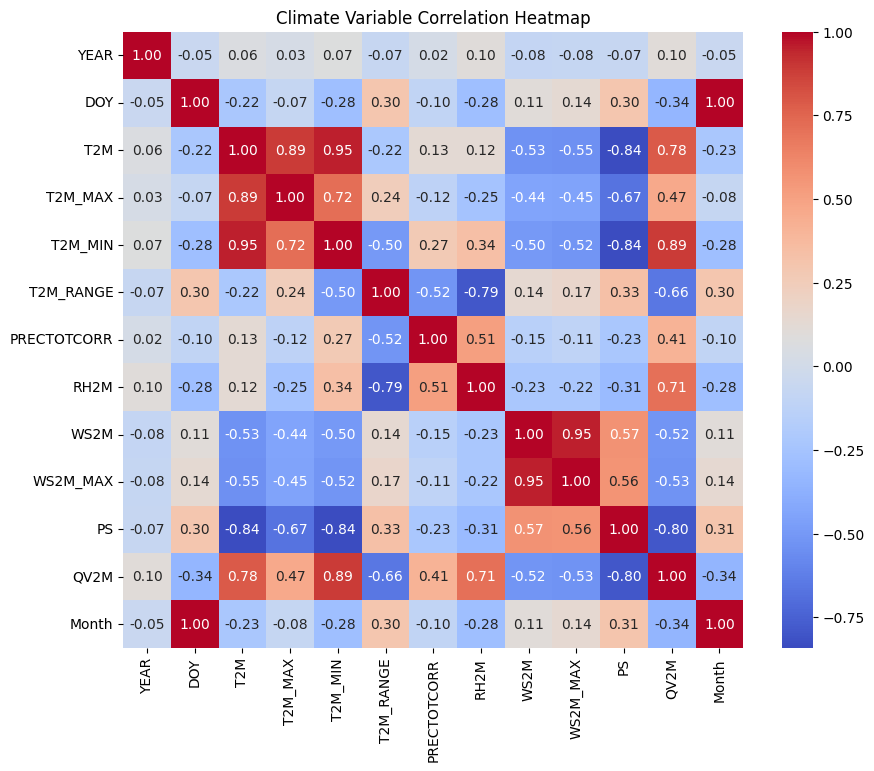

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Climate Variable Correlation Heatmap')
plt.show()

**Exporting Cleaned Data**

In [8]:
import os
if not os.path.exists('../data'):
    os.makedirs('../data')
df.to_csv("../data/tanzania_clean.csv")
print("Cleaned data exported to data/tanzania_clean.csv")

Cleaned data exported to data/tanzania_clean.csv
